In [16]:
import torch, numpy as np
from botorch.test_functions.multi_fidelity import AugmentedHartmann, AugmentedBranin
from botorch.models.cost import AffineFidelityCostModel
#, BoreholeMultiFidelity, WingWeightMultiFidelity
from botorch.models.gp_regression_fidelity import SingleTaskMultiFidelityGP
from botorch.models.transforms.outcome import Standardize
from botorch.models.transforms.input import Normalize
from botorch.exceptions.errors import ModelFittingError
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood
from botorch.acquisition.utils import project_to_target_fidelity
from botorch.acquisition.monte_carlo import qExpectedImprovement
from botorch.acquisition.analytic import LogProbabilityOfImprovement
from botorch.optim import optimize_acqf
from torch.distributions.normal import Normal
from botorch import fit_gpytorch_mll
from botorch.acquisition.fixed_feature import FixedFeatureAcquisitionFunction
from botorch.acquisition import PosteriorMean
from matplotlib.ticker import FormatStrFormatter, MultipleLocator
from linear_operator.settings import cholesky_jitter
from gpytorch.constraints import GreaterThan
import warnings
warnings.filterwarnings('ignore')
from botorch.acquisition.acquisition import AcquisitionFunction
from botorch.acquisition.analytic import AnalyticAcquisitionFunction
from torch.distributions.normal import Normal
import torch
from typing import Callable
from botorch.utils.transforms import t_batch_mode_transform
from __future__ import annotations
import time
import gpytorch
import matplotlib.pyplot as plt

tkwargs = {"dtype": torch.double, "device": "cpu"}
device = torch.device("cpu")
dtype = torch.double

In [2]:
def draw_initial(
    f,
    n: int = 20,
    flag_two_fid: bool = False,
):
    """
    Generate an initial design with *continuous* fidelities.

    flag_two_fid = False  -> layout [x_part , s]
    flag_two_fid = True   -> layout [x_part , s1 , s2]

    Assumes:
      - f.dim is the total input dimension
      - The last 1 (or 2) dimensions of f.bounds are fidelity dims.
    """

    # number of pure design dimensions
    dim_x = f.dim - (2 if flag_two_fid else 1)
    bounds = f.bounds.clone().to(dtype=dtype, device=device)

    # ------------------------------------------------------------------#
    # 1) sample design variables x in their physical bounds
    # ------------------------------------------------------------------#
    low_x  = bounds[0, :dim_x]        # (dim_x,)
    high_x = bounds[1, :dim_x]        # (dim_x,)

    u_x    = torch.rand(n, dim_x, dtype=torch.double, device=device)
    x_part = low_x + (high_x - low_x) * u_x      # (n , dim_x)

    # ------------------------------------------------------------------#
    # 2) sample continuous fidelity variable(s) from their bounds
    # ------------------------------------------------------------------#
    n_fid   = 2 if flag_two_fid else 1
    low_s   = bounds[0, dim_x: dim_x + n_fid]    # (n_fid,)
    high_s  = bounds[1, dim_x: dim_x + n_fid]    # (n_fid,)

    u_s     = torch.rand(n, n_fid, dtype=torch.double, device=device)
    s_part  = low_s + (high_s - low_s) * u_s     # (n, n_fid)

    # ------------------------------------------------------------------#
    # 2b) Force a proportion of initial points to be at highest fidelity
    # ------------------------------------------------------------------#
    # Choose how many high-fidelity points you want in the initial design.
    # Here: 20% of n (at least 1), change 0.20 to whatever proportion you want.
    hf_prop = 0.20
    n_hf = max(1, int(round(hf_prop * n)))

    # Randomly pick which rows become high-fidelity
    idx = torch.randperm(n, device=device)[:n_hf]

    # Set all fidelity dims to 1.0 for those rows
    s_part[idx, :] = 1.0

    # ------------------------------------------------------------------#
    # 3) build the full X matrix
    # ------------------------------------------------------------------#
    X0 = torch.cat([x_part, s_part], dim=-1)      # (n , dim_x + n_fid)

    Y0 = f(X0).unsqueeze(-1)
    return X0, Y0


In [3]:
def fit_mf_gp(X: torch.Tensor, Y: torch.Tensor, fid_dims) -> SingleTaskMultiFidelityGP:
    # Allow passing a single int or a list of ints
    if isinstance(fid_dims, int):
        fid_dims = [fid_dims]

    model = SingleTaskMultiFidelityGP(
        train_X=X,
        train_Y=Y,
        data_fidelities=fid_dims,
        linear_truncated=True,
        outcome_transform=Standardize(m=1),
    ).to(dtype=torch.double, device=device)

    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    fit_gpytorch_mll(mll)
    return model



In [13]:
class MFPI(AnalyticAcquisitionFunction):
    """
    Cost-aware multi-fidelity PI for q=1 and continuous fidelities.

    For a candidate X (shape: batch x 1 x d) with x in first dim_x dims
    and fidelity dims in the last one or two dims, the stage value is:

        PI_hi(x) * ρ((x,s), (x,s_hi)) * cost(s_hi) / cost(s)

    where:
      - PI_hi(x) is analytic PI at the *high* fidelity s_hi
      - ρ is the posterior correlation between (x,s) and (x,s_hi)
      - cost(·) is given by an AffineFidelityCostModel
    """

    def __init__(
        self,
        model,
        dim_x: int,
        s_hi: float,
        cost_model: AffineFidelityCostModel,
        best_f: float,
        eps: float = 1e-9,
        posterior_transform=None,
        debug: bool = False,
        max_debug_calls: int = 6,
        **kwargs,
    ):
        super().__init__(model=model, posterior_transform=posterior_transform)
        self.dim_x        = int(dim_x)
        self.s_hi         = float(s_hi)
        self.cost_model   = cost_model
        self.best_f       = float(best_f)
        self.eps          = eps
        self._dbg         = debug
        self._dbg_count   = 0
        self._dbg_limit   = int(max_debug_calls)

        # standard normal for PI formula
        self._std_normal = Normal(
            torch.zeros(
                1,
                dtype=model.train_targets.dtype,
                device=model.train_targets.device,
            ),
            torch.ones(
                1,
                dtype=model.train_targets.dtype,
                device=model.train_targets.device,
            ),
        )

    def _stats(self, name: str, t: torch.Tensor):
        """Print shape + basic stats – robust to empty tensors."""
        if not self._dbg:
            return
        s = f"{name:10}  shape={tuple(t.shape)}"
        if t.numel() == 0:
            print(s + "  EMPTY")
            return
        with torch.no_grad():
            s += (
                f"  min={float(t.min()):.3e}  max={float(t.max()):.3e}  "
                f"nan={(~torch.isfinite(t)).sum().item()}  "
                f"inf={(torch.isinf(t)).sum().item()})"
            )
        print(s)

    @t_batch_mode_transform(expected_q=1)
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        X: batch_shape x 1 x d
        """
        if self._dbg:
            print(f"\n==== forward call {self._dbg_count} ====")
            self._dbg_count += 1
            self._stats("X in", X)


        # Extract single point per batch: (..., d)

        X0 = X[..., 0, :]
        d_total = X0.shape[-1]
        dim_x = self.dim_x

        # Split into design and fidelity parts
        xd = X0[..., :dim_x]                # (..., dim_x)
        s  = X0[..., dim_x:]                # (..., n_fid)  with n_fid = d_total - dim_x

        # Build high-fidelity point (same x, all fidelities = s_hi)
        s_hi = torch.full_like(s, self.s_hi)
        X_hi0 = torch.cat([xd, s_hi], dim=-1)   # (..., d_total)
        X_s0  = X0                              # (..., d_total)

        # Stack (x, s) and (x, s_hi) for joint posterior
        X_pair = torch.stack([X_s0, X_hi0], dim=-2)   # (..., 2, d_total)
        self._stats("X_pair", X_pair)


        # Posterior for both fidelities at once

        with gpytorch.settings.fast_pred_var(True):
            post_pair = self.model.posterior(
                X_pair,
                posterior_transform=self.posterior_transform,
                observation_noise=False,
            )


        # Means / variances

        mean2 = post_pair.mean.squeeze(-1)                     # (..., 2)
        mu_hi = mean2[..., 1]

        var2  = post_pair.variance.squeeze(-1).clamp_min(self.eps)  # (..., 2)
        var_ss, var_hh = var2[..., 0], var2[..., 1]

        # Off-diagonal covariance Cov[(x,s), (x,s_hi)]
        mvn = post_pair.mvn
        cov_sh = mvn.covariance_matrix[..., 0, 1]              # (...,)

        # Correlation ρ
        rho = (cov_sh / (var_ss.sqrt() * var_hh.sqrt())).clamp(-1.0, 1.0)
        rho = torch.nan_to_num(rho, nan=0.0, posinf=0.0, neginf=0.0)
        self._stats("rho", rho)


        # Analytic PI at high fidelity using mu_hi, var_hh

        sigma = var_hh.sqrt()
        z     = (mu_hi - self.best_f) / sigma
        z = torch.nan_to_num(z, nan=0.0, posinf=1e6, neginf=-1e6)
        pi    = self._std_normal.cdf(z)
        pi = torch.nan_to_num(pi, nan=0.0, posinf=1.0, neginf=0.0)
        self._stats("PI", pi)


        # Cost ratio: cost(x, s_hi) / cost(x, s)
        # cost_model expects shape (..., q, d), so give q=1

        cost_hi = self.cost_model(X_hi0.unsqueeze(-2)).squeeze(-1).squeeze(-1)
        cost_s  = self.cost_model(X).squeeze(-1).squeeze(-1)
        cost_ratio = cost_hi / cost_s
        cost_ratio = torch.nan_to_num(cost_ratio, nan=1.0, posinf=1.0, neginf=1.0)
        self._stats("cost ratio", cost_ratio)


        # Final value
        val = pi * rho * (cost_ratio)
        self._stats("val", val)

        return val


In [17]:
def min_normalized_distance(x_new: torch.Tensor, X_existing: torch.Tensor, bounds: torch.Tensor) -> float:
    span = (bounds[1] - bounds[0]).clamp_min(1e-12)
    x_new_n = (x_new - bounds[0]) / span
    X_existing_n = (X_existing - bounds[0]) / span
    return torch.cdist(x_new_n, X_existing_n).min().item()


def sample_nonduplicate_candidate(
    bounds: torch.Tensor,
    X_existing: torch.Tensor,
    min_dist_tol: float,
    fid_dims,
    s_hi: float,
    force_hf: bool,
    n_tries: int = 256,
) -> torch.Tensor | None:
    low, high = bounds[0], bounds[1]

    for _ in range(n_tries):
        cand = low + (high - low) * torch.rand(
            1, bounds.shape[1], dtype=bounds.dtype, device=bounds.device
        )

        if force_hf:
            cand = cand.clone()
            for d in fid_dims:
                cand[0, d] = torch.as_tensor(s_hi, dtype=cand.dtype, device=cand.device)

        if min_normalized_distance(cand, X_existing, bounds) >= min_dist_tol:
            return cand

    return None


In [26]:
from botorch.acquisition import PosteriorMean
from botorch.acquisition.fixed_feature import FixedFeatureAcquisitionFunction
def run_cost_aware_mfpi_bo_once(
    f: Callable,
    T: int = 30,
    init_n: int = 16,
    s_hi: float = 1.0,
    cost_dict = None,   # now a config for affine cost: {"fixed_cost": ..., "w": ...} or {"fixed_cost": ..., "w1": ..., "w2": ...}
    seed = None,
    per_run_plots: bool = True,
    flag_two_fid: bool = False,
):
    """
    One cost-aware multi-fidelity PI run with continuous fidelities.

    Returns dict with keys:
        cum_cost, best_hi
    """
    if seed is not None:
        torch.manual_seed(int(seed))
        np.random.seed(int(seed))

    # ---------------------------------------------------------------
    # Dimensions & fidelity indices
    # ---------------------------------------------------------------
    if flag_two_fid:
        dim_x   = f.dim - 2
        d_total = f.dim
        fid_dims = [f.dim - 2, f.dim - 1]   # last two dims are fidelities
    else:
        dim_x   = f.dim - 1
        d_total = f.dim
        fid_dims = [f.dim - 1]              # last dim is fidelity

    bounds = f.bounds.clone().detach().to(**tkwargs)

    # ---------------------------------------------------------------
    # Affine cost model: cost = fixed_cost + Σ w_j * s_j
    # (s_j are the fidelity coordinates)
    # ---------------------------------------------------------------
    if cost_dict is None:
        # reasonable default
        cost_dict = {"fixed_cost": 1.0, "w": 1.0}

    fixed_cost = float(cost_dict.get("fixed_cost", 1.0))
    if len(fid_dims) == 1:
        w = float(cost_dict.get("w", 1.0))
        fidelity_weights = {fid_dims[0]: w}
    else:
        w1 = float(cost_dict.get("w1", 1.0))
        w2 = float(cost_dict.get("w2", 1.0))
        fidelity_weights = {
            fid_dims[0]: w1,
            fid_dims[1]: w2,
        }

    cost_model = AffineFidelityCostModel(
        fidelity_weights=fidelity_weights,
        fixed_cost=fixed_cost,
    )

    # ---------------------------------------------------------------
    # Initial design & initial GP
    # ---------------------------------------------------------------
    X, Y = draw_initial(f, init_n, flag_two_fid=flag_two_fid)
    print(f"X values are : {X.tolist()}")
    print(f"Y values are : {Y.squeeze(-1).tolist()}")    

    iter_idx, cum_cost_hist, best_hi_hist = [], [], []

    model = fit_mf_gp(X, Y, fid_dims)
    total_cost = 0.0
    prev_best = float("-inf")
    current_best = prev_best
    t = 0
    # ---------------------------------------------------------------
    # BO loop
    # ---------------------------------------------------------------
    iters_since_hf = 0  # number of consecutive BO iters without an HF eval
    for t in range(T): 
        # Re-fit model each iteration (optional; we already fit above)
        model = fit_mf_gp(X, Y, fid_dims)

        # Current best at high fidelity s_hi in *all* fidelity dims
        tol = 1e-2
        hf_mask = torch.ones(X.shape[0], dtype=torch.bool, device=X.device)
        for d in fid_dims:
            hf_mask &= torch.isclose(
                X[:, d],
                torch.as_tensor(s_hi, dtype=X.dtype, device=X.device),
                atol=tol, rtol=0.0,
            )



        y_max = Y[hf_mask].max()


        best_f_value = float(y_max.item())

        # -----------------------------------------------------------
        # Every 5 iterations: ensure at least one evaluation at s_hi
        # in the most recent 5 BO samples (new_x's).
        # If none, force this iteration to evaluate at s_hi.
        # -----------------------------------------------------------
        # force_hf = ((t + 1) % 5 == 0) and (iters_since_hf >= 4)
        hf_exploit = ((t + 1) % 9 == 0) and (iters_since_hf >= 8)
        if (t + 1) % 9 == 0:
            # look at the last up-to-5 evaluated points so far
            last_k = min(9, X.shape[0])
            X_recent = X[-last_k:]

            tol_hf = 1e-2
            recent_hf_mask = torch.ones(X_recent.shape[0], dtype=torch.bool, device=X.device)
            for d in fid_dims:
                recent_hf_mask &= torch.isclose(
                    X_recent[:, d],
                    torch.as_tensor(s_hi, dtype=X.dtype, device=X.device),
                    atol=tol_hf, rtol=0.0,
                )

            if not recent_hf_mask.any():
                hf_exploit = True


        if hf_exploit:
            hf_logpi = LogProbabilityOfImprovement(
                model=model,
                best_f=best_f_value,
            )
            fixed_features = {d: float(s_hi) for d in fid_dims}

            new_x, _ = optimize_acqf(
                acq_function=hf_logpi,
                bounds=bounds,
                q=1,
                num_restarts=12,
                raw_samples=512,
                fixed_features=fixed_features,
                options={"batch_limit": 5, "maxiter": 200},
            )

        else:
            # -------------------------------------------------------
            # Regular step: maximize cost-aware MFPI (fidelity free)
            # -------------------------------------------------------
            acqf = MFPI(
                model=model,
                dim_x=dim_x,
                s_hi=s_hi,
                cost_model=cost_model,
                best_f=best_f_value,
                debug=False,
            )

            new_x, _ = optimize_acqf(
                acq_function=acqf,
                bounds=bounds,
                q=1,
                num_restarts=12,
                raw_samples=256,
                options={"batch_limit": 5, "maxiter": 200},
            )

        # If we must sample high fidelity on this iteration, overwrite fidelity dim(s)
        # if force_hf:
        if hf_exploit:
            new_x = new_x.clone()
            for d in fid_dims:
                new_x[0, d] = torch.as_tensor(s_hi, dtype=new_x.dtype, device=new_x.device)
                
        # Update HF counter
        tol_hf = 1e-2
        is_hf = True
        for d in fid_dims:
            is_hf = is_hf and torch.isclose(
                new_x[0, d],
                torch.as_tensor(s_hi, dtype=new_x.dtype, device=new_x.device),
                atol=tol_hf, rtol=0.0,
            ).item()

        iters_since_hf = 0 if is_hf else (iters_since_hf + 1)

        # Reject exact / near-duplicate candidates before evaluating and appending.
        min_dist_tol = 5e-3  # normalized distance; try 1e-2 if you still get clustering

        cand_dist = min_normalized_distance(new_x, X, bounds)
        if cand_dist < min_dist_tol:
            print(f"Rejecting near-duplicate candidate: min normalized dist = {cand_dist:.3e}")

            alt_x = sample_nonduplicate_candidate(
                bounds=bounds,
                X_existing=X,
                min_dist_tol=min_dist_tol,
                fid_dims=fid_dims,
                s_hi=s_hi,
                force_hf=hf_exploit,
                n_tries=256,
            )

            if alt_x is not None:
                new_x = alt_x
                print("Replaced with random non-duplicate candidate.")
            else:
                print("Warning: could not find a non-duplicate fallback; keeping original candidate.")

                
        new_y = f(new_x).view(1, 1)

        # Cost of this evaluation via affine cost model
        cost_t = cost_model(new_x).squeeze(-1).squeeze(-1).item()
        total_cost += cost_t

        cum_cost_hist.append(total_cost)
        iter_idx.append(t + 1)

        X = torch.cat([X, new_x], dim=0)
        Y = torch.cat([Y, new_y], dim=0)

        # Update best high-fidelity value
        tol = 1e-2
        hf_mask = torch.ones(X.shape[0], dtype=torch.bool, device=X.device)
        for d in fid_dims:
            hf_mask &= torch.isclose(
                X[:, d],
                torch.as_tensor(s_hi, dtype=X.dtype, device=X.device),
                atol=tol, rtol=0.0,
            )

        if hf_mask.any():
            prev_best = Y[hf_mask].max().item()
        current_best = prev_best
        best_hi_hist.append(current_best)

        # Progress print
        if t % 1 == 0 or t == T - 1:
            s_vals = X[-1, fid_dims].tolist()
            s_str = ", ".join(f"{sv:.3f}" for sv in s_vals)
            print(
                f"Iter {t+1:02d} | s=[{s_str}] | y={new_y.item():.6f} "
                f"| cost={cost_t:.6f} | cum_cost={total_cost:.6f} "
                f"| best_hf={current_best:.6f}"
            )
    
    # ---------------------------------------------------------------
    # Plots
    # ---------------------------------------------------------------
    if per_run_plots:
        plt.figure()
        plt.plot(cum_cost_hist, best_hi_hist, linewidth=1)
        plt.xlabel("Cumulative cost")
        plt.ylabel(f"Best observed @ s≈{s_hi}")
        plt.title("Best high fidelity vs cumulative cost")
        plt.grid(True)
        plt.show()

    # ---------------------------------------------------------------
    # Return results
    # ---------------------------------------------------------------
    return {
        "cum_cost": cum_cost_hist,
        "best_hi":  best_hi_hist,
    }


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tests import AugmentedBukin, AugmentedRastrigin, AugmentedAckley
from tests_pc import SuzukiMFEmulator

def run_single(f, seed: int, total_iters: int = 35):
    """Run a single BO experiment and return a DataFrame of its trajectory.

    Assumes continuous fidelity variable(s) and that run_cost_aware_mfpi_bo_once
    interprets cost_dict as:
      - one fidelity dim:  {"fixed_cost": c0, "w": w}
            cost(s) = c0 + w * s
      - two fidelity dims: {"fixed_cost": c0, "w1": w1, "w2": w2}
            cost(s1, s2) = c0 + w1 * s1 + w2 * s2
    """

    # -------------------------------------------------------
    # pick defaults based on the *type* of f
    # -------------------------------------------------------
    if isinstance(f, AugmentedHartmann):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False     # 1 fidelity dim (last column)
        s_hi        = 1.0        # high fidelity at s = 1

    elif isinstance(f, AugmentedBranin):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False
        s_hi        = 1.0

    elif isinstance(f, (AugmentedBukin, AugmentedRastrigin, AugmentedAckley)):
        cost_dict   = {"fixed_cost": 5.0, "w": 1.0}
        flag_two_fid = False
        s_hi        = 1.0

    # elif isinstance(f, AugmentedRosenbrock):
    #     cost_dict   = {"fixed_cost": 5.0, "w1": 1.0, "w2": 1.0}
    #     flag_two_fid = True      # 2 fidelity dims (last two columns)
    #     s_hi        = 1.0        # high fidelity at (1,1)

    elif isinstance(f, SuzukiMFEmulator):
        cost_dict    = {"fixed_cost": 5.0, "w": 1.0}  # cost increases with fidelity
        flag_two_fid = False
        s_hi         = 1.0



    else:
        raise ValueError(
            "Unknown function"
        )

    # -------------------------------------------------------
    # run the BO loop with those settings
    # -------------------------------------------------------
    results = run_cost_aware_mfpi_bo_once(
        f=f,
        T=total_iters,
        init_n=32,
        s_hi=s_hi,
        cost_dict=cost_dict,
        seed=seed,
        per_run_plots=True,
        flag_two_fid=flag_two_fid,
    )

    df = pd.DataFrame({
        "iteration":       np.arange(1, len(results["cum_cost"]) + 1),
        "cumulative_cost": results["cum_cost"],
        "best_hi":         results["best_hi"],
    })
    return df



def aggregate_runs(dfs):
    """Stack per-run dataframes and compute mean & std."""
    merged = (
        pd.concat(
            {i: df.set_index("iteration") for i, df in enumerate(dfs)},
            names=["run", "iteration"],
        )
        .reset_index(level="run")
    )
    stats = (
        merged.groupby("iteration")
        .agg(["mean", "std"])  # adds a 2-level column index
    )
    # Flatten multi-index columns: e.g. ('cumulative_cost','mean') → 'cumulative_cost_mean'
    stats.columns = [f"{col}_{stat}" for col, stat in stats.columns]
    return stats.reset_index()

def plot_with_band(iterations, mean, std, ylabel, title):
    plt.figure()
    # plt.ylim(3.251, 3.291)
    plt.plot(iterations, mean, lw=2, label="mean")
    plt.fill_between(iterations, mean - std, mean + std, alpha=0.25, label="±1 σ")
    plt.xlabel("Iteration")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()

def plot_best_vs_cost(cost_mean, cost_std, best_mean, best_std,
                      title="Best observed vs. cumulative cost (mean ± 1 σ)",
                      optimum_val=None):
    """
    Scatter-line plot of mean best-observed value vs mean cumulative cost,
    with a shaded ±1 σ region around the best value.
    """
    # sort by cost so the line is monotone
    order = np.argsort(cost_mean)
    cost_mean, best_mean = cost_mean.iloc[order], best_mean.iloc[order]
    best_std            = best_std.iloc[order]

    plt.figure()
    plt.plot(cost_mean, best_mean, lw=2, label="mean trajectory")
    plt.fill_between(cost_mean,
                     best_mean - best_std,
                     best_mean + best_std,
                     alpha=0.25,
                     label="±1 σ (best)")
    if optimum_val is not None:
        plt.axhline(optimum_val, ls="--", label=f"True optimum = {optimum_val}")

    plt.xlabel("Cumulative cost (mean)")
    plt.ylabel("Best observed hi-fidelity value (mean)")
    plt.title(title)
    plt.grid(True)
    plt.legend()
    plt.tight_layout()



=== Running hartmann (iters=63) ===
X values are : [[0.948740334359443, 0.5496638628392889, 0.60675951036992, 0.0937772321424507, 0.570361495458435, 0.9617708267957583, 0.3448496560224914], [0.26660006068322173, 0.26015371313699054, 0.5632481702669822, 0.5324858748380357, 0.3749362094276564, 0.680609208569693, 0.5278507447794409], [0.9339096371292985, 0.6824112449414603, 0.1248048523742955, 0.5256428547632006, 0.5265312662769164, 0.8419891251251695, 1.0], [0.16452472854917877, 0.24491302053081732, 0.3557790632215262, 0.4294467962038431, 0.45334685117401774, 0.7351700886479454, 0.5692894575213924], [0.009023456986727352, 0.3339200591669311, 0.7112579918990516, 0.15196843815970462, 0.8507202446451545, 0.6991511889547046, 0.7413394395513939], [0.1533458876152125, 0.5742454376478688, 0.42458947929659996, 0.8643486615283732, 0.9555430625193861, 0.8540503873763837, 0.42222798762488645], [0.512650062190536, 0.5470653171735067, 0.6470713147908671, 0.5661811902591023, 0.5270024121368904, 0.987

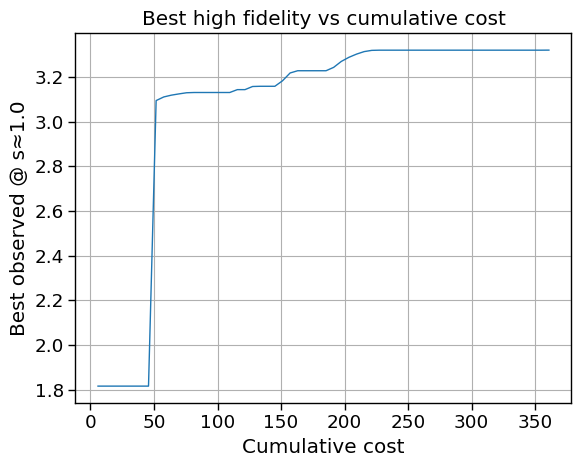

X values are : [[0.05815448596142969, 0.06291016742457756, 0.12358607277440903, 0.05258016436107704, 0.5261718968547618, 0.47678475378747964, 0.05616993076150212], [0.9552357002491416, 0.9287525814574296, 0.08354336875286783, 0.13264067215369857, 0.15705349751070807, 0.3753670320505006, 1.0], [0.8425197308314868, 0.8705010417836975, 0.3775329552705594, 0.6124365889937913, 0.088109784914571, 0.7011818919498007, 0.33301176017348855], [0.6234030833542006, 0.43727899779065216, 0.07473487847374805, 0.683430217106661, 0.31223868072296257, 0.30905877722327246, 0.1811994077481407], [0.03134016542741558, 0.04036646765995722, 0.9319087898549986, 0.15212582742256442, 0.26504491174836087, 0.13043349263210446, 0.757224963503427], [0.2518552209413236, 0.2334081890579478, 0.22566509879348662, 0.3175677977570315, 0.6144082848015856, 0.5977713515360384, 0.2818006784078072], [0.8490028457480704, 0.0324956087559799, 0.30924379397653057, 0.43230375445533953, 0.9342988061888965, 0.12231294307466178, 0.7530

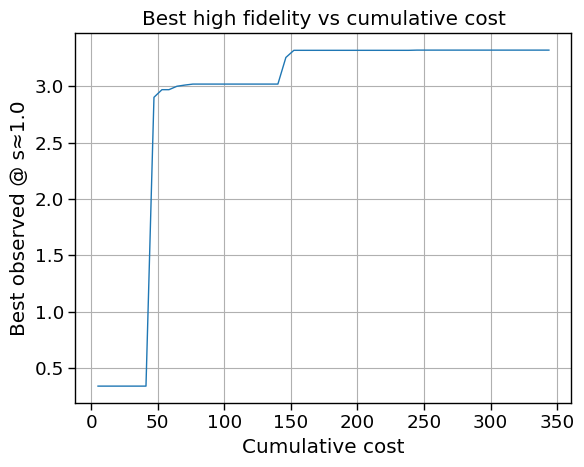

X values are : [[0.18455152901586658, 0.6425551928844496, 0.04314167614835407, 0.5920895205610532, 0.5819555432343702, 0.8804650927201698, 1.0], [0.10900633406816063, 0.33424518984105245, 0.7164665076605705, 0.6113622764948545, 0.056316941923797326, 0.2462955941360654, 0.214943059173495], [0.16064961779305054, 0.2101580126188637, 0.5519271821259594, 0.759278288316592, 0.41992092694002725, 0.5534430256198113, 0.2680863122174636], [0.8008797515898193, 0.8313474996369212, 0.618606939300293, 0.13524995437485876, 0.029420457929205335, 0.9673911796899787, 0.5513924018700581], [0.7781435418234086, 0.2606150428095527, 0.5476397648233069, 0.9976919401787342, 0.315915775696601, 0.8776442554703325, 0.6052643276945909], [0.8693788416071722, 0.3713906517827037, 0.8064880290347203, 0.655466707837252, 0.45108827923356354, 0.6201039955361694, 0.1450512914015898], [0.26283361669775596, 0.8861246911065979, 0.6435346306416617, 0.4133140714006799, 0.3245213245554963, 0.4377124814255394, 1.0], [0.292475998

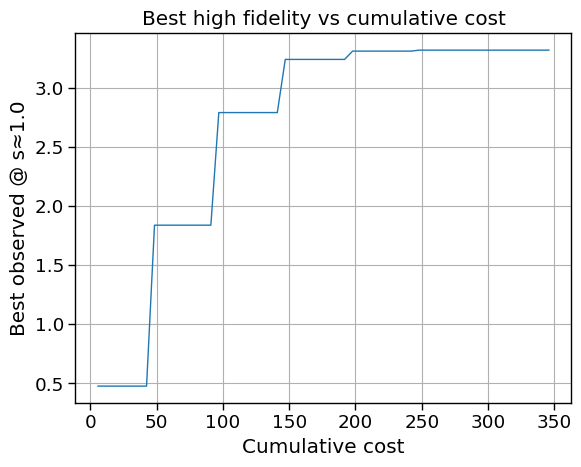

X values are : [[0.49935928738848523, 0.020884919278622793, 0.960558247349443, 0.4466251926601825, 0.9908069297884947, 0.4362398858913822, 1.0], [0.9172090248725108, 0.5982406543817721, 0.8853833320438047, 0.6529512299063377, 0.813978208058021, 0.7015666815692355, 0.2916473845867803], [0.5006556131405895, 0.7660968249414171, 0.7973165072496673, 0.19068436062085248, 0.8955174874293743, 0.6050274766964561, 0.7895173099156824], [0.22067144328464028, 0.556940537587595, 0.9502645529066469, 0.6357229079655891, 0.840153099796869, 0.24148301931183047, 0.5540555992163712], [0.3467041326745913, 0.9039344690919432, 0.19906175195650022, 0.3264170944200183, 0.7513761884046478, 0.12536642283602561, 1.0], [0.509391267609735, 0.4399404018360964, 0.0289593936053405, 0.5534413518180936, 0.09470755827457444, 0.5973938638861206, 0.6383539882493622], [0.2939381790068638, 0.9897975199263006, 0.4546017385286679, 0.7586595907283213, 0.9257816060999862, 0.9075895137130191, 0.6173435553741498], [0.6773879293111

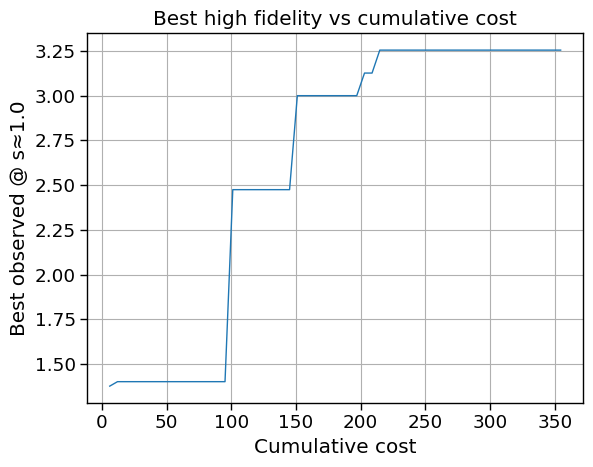

X values are : [[0.9037188298339972, 0.9383291966213895, 0.7080114464805504, 0.10004131307878639, 0.8757494880343326, 0.09690530225461702, 0.6355347177552323], [0.5309008389164401, 0.7736095995002673, 0.33186522925320694, 0.04159093613298781, 0.04463156992793571, 0.14873431554655314, 0.7362710229528411], [0.24244744755586578, 0.2770664834403107, 0.6922700784855981, 0.4551663384568625, 0.8332709106326528, 0.7617079293331473, 1.0], [0.8372751281016203, 0.2971052368648113, 0.45060525170881105, 0.8580143327829626, 0.44307405448320725, 0.7403739328980725, 1.0], [0.8008514339881768, 0.02293900285878303, 0.4506218373128157, 0.9580985397932351, 0.6134912250489626, 0.7420077591864331, 0.010451835264580267], [0.8112033856590298, 0.8970470336718052, 0.406818337154809, 0.5705318913041604, 0.3701454792059824, 0.39237781187839493, 1.0], [0.5939393245736355, 0.9385512973557394, 0.6756456308250632, 0.4946866474856294, 0.7129244193636504, 0.8731696574477062, 1.0], [0.8217989839645193, 0.010080527293074

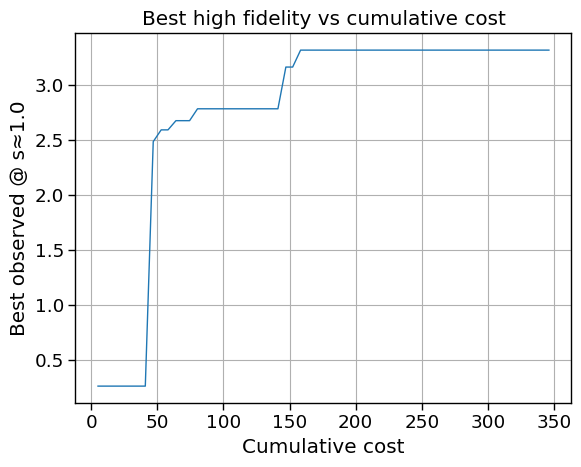

X values are : [[0.5387688513648883, 0.13084315422979265, 0.33473787207152206, 0.04282105817538684, 0.5647563104875424, 0.900136342815163, 0.9399575905254955], [0.15897178551798263, 0.7119021562282158, 0.9139133217762426, 0.18232712850008148, 0.7868406176208578, 0.708535627006607, 0.7522288682900041], [0.42153606977181757, 0.7933706376295209, 0.8144107440881847, 0.07236398346578865, 0.9100765234022539, 0.34591058279153186, 0.11305001948957127], [0.3804952826886925, 0.7843835440921516, 0.3787660768834513, 0.2992094854563706, 0.11747196006380367, 0.9088214291913526, 1.0], [0.2582190223162393, 0.9124549715751364, 0.08648887441168529, 0.7702178544610285, 0.6708083513536468, 0.8633094070114542, 0.14455179213822333], [0.9061053962370172, 0.1374153274166724, 0.6587179493362595, 0.6943967399407722, 0.206498905622168, 0.7400482873398703, 0.4008655580187849], [0.2878863472932276, 0.1083107204571434, 0.8946016692229378, 0.7881669111459213, 0.9846573203718824, 0.19803804476247533, 0.49390496370860

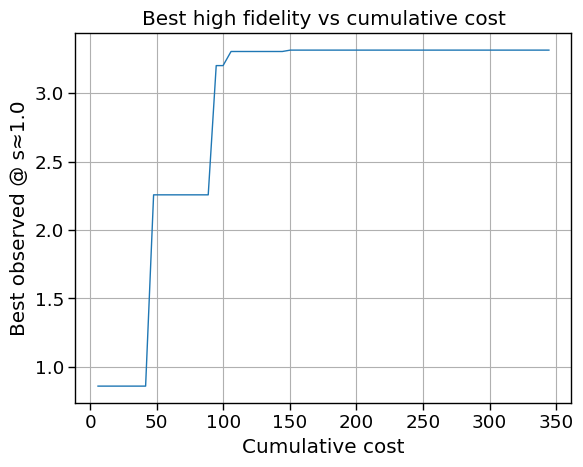

Saved aggregate stats → mf_pi_runs_cont_hartmann.csv


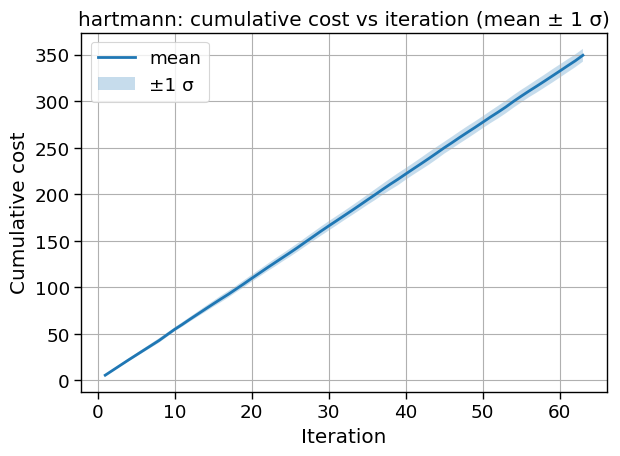

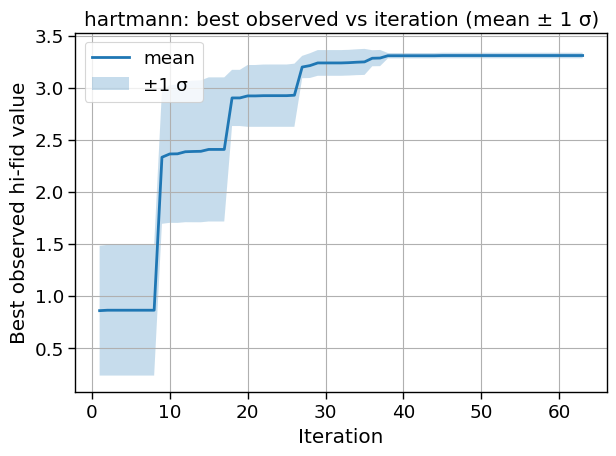

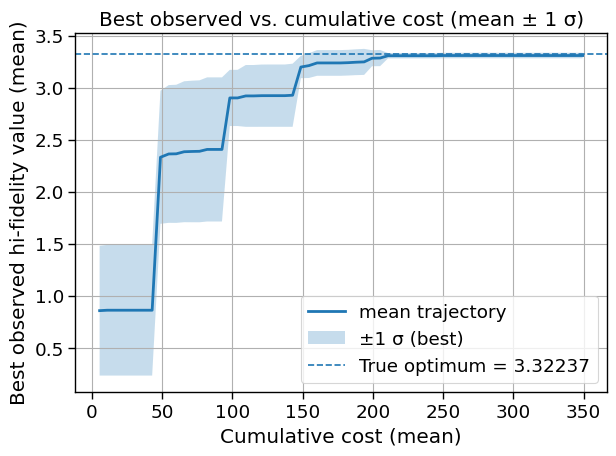

In [27]:
import matplotlib.pyplot as plt
from collections import OrderedDict


# ------------------------------------------------------------------
# 0)  Benchmarks and their custom settings
# ------------------------------------------------------------------
benchmarks = OrderedDict([
    ("hartmann",   (AugmentedHartmann(negate=True), 63,  3.32237)),
    # ("branin",     (AugmentedBranin(negate=True), 54, -0.3978)),
    # ("bukin",      (AugmentedBukin(negate=True), 50, -0.0)),
    # ("ackley",  (AugmentedAckley(dim=3, negate=True), 57,  0.0)),
    # ("rastrigin",  (AugmentedRastrigin(dim=3, negate=True), 50, -0.0)),
    # ("suzuki_mf", (SuzukiMFEmulator(num_samples=32, stochastic=True),60, None)),
])

SEEDS = [ 33, 42, 88, 105, 67, 151,]  # 6 runs each 
# ------------------------------------------------------------------

# 1)  Loop over benchmarks
# ------------------------------------------------------------------
for tag, (f, total_iters, opt_val) in benchmarks.items():
    print(f"\n=== Running {tag} (iters={total_iters}) ===")

    # 1a) independent runs
    run_dfs = [run_single(f=f, seed=s, total_iters=total_iters) for s in SEEDS]

    # 1b) aggregate & save
    stats_df = aggregate_runs(run_dfs)
    out_csv  = f"mf_pi_runs_cont_{tag}.csv"
    stats_df.to_csv(out_csv, index=False)
    print(f"Saved aggregate stats → {out_csv}")

    # 1c) plots
    iters = stats_df["iteration"]

    plot_with_band(
        iters,
        stats_df["cumulative_cost_mean"],
        stats_df["cumulative_cost_std"],
        ylabel="Cumulative cost",
        title=f"{tag}: cumulative cost vs iteration (mean ± 1 σ)",
    )

    plot_with_band(
        iters,
        stats_df["best_hi_mean"],
        stats_df["best_hi_std"],
        ylabel="Best observed hi-fid value",
        title=f"{tag}: best observed vs iteration (mean ± 1 σ)",
    )

    plot_best_vs_cost(
        cost_mean=stats_df["cumulative_cost_mean"],
        cost_std=stats_df["cumulative_cost_std"],
        best_mean=stats_df["best_hi_mean"],
        best_std=stats_df["best_hi_std"],
        optimum_val=opt_val,          # show dashed line only if not None
    )
    plt.show()
# ------------------------------------------------------------------
